In [1]:
import tensorflow as tf
import numpy as np

In [ ]:
data = np.loadtxt('./data/data-01-test-score.csv', delimiter=',', dtype=np.float32)

x_data = data[:, 0:-1] # 학습 데이터, 처음 부터 마지막 데이터 직전까지 정답 데이터제외
y_data = data[:, [-1]] # 정답 데이터

In [3]:
print(x_data, 'x_data shape:', x_data.shape)
print(y_data, 'y_data shape:', y_data.shape)

[[ 73.  80.  75.]
 [ 93.  88.  93.]
 [ 89.  91.  90.]
 [ 96.  98. 100.]
 [ 73.  66.  70.]
 [ 53.  46.  55.]
 [ 69.  74.  77.]
 [ 47.  56.  60.]
 [ 87.  79.  90.]
 [ 79.  70.  88.]
 [ 69.  70.  73.]
 [ 70.  65.  74.]
 [ 93.  95.  91.]
 [ 79.  80.  73.]
 [ 70.  73.  78.]
 [ 93.  89.  96.]
 [ 78.  75.  68.]
 [ 81.  90.  93.]
 [ 88.  92.  86.]
 [ 78.  83.  77.]
 [ 82.  86.  90.]
 [ 86.  82.  89.]
 [ 78.  83.  85.]
 [ 76.  83.  71.]
 [ 96.  93.  95.]] x_data shape: (25, 3)
[[152.]
 [185.]
 [180.]
 [196.]
 [142.]
 [101.]
 [149.]
 [115.]
 [175.]
 [164.]
 [141.]
 [141.]
 [184.]
 [152.]
 [148.]
 [192.]
 [147.]
 [183.]
 [177.]
 [159.]
 [177.]
 [175.]
 [175.]
 [149.]
 [192.]] y_data shape: (25, 1)


In [4]:
tf.model = tf.keras.Sequential()

In [6]:
# 입력 레이어 추가 .Input()
tf.model.add(tf.keras.Input(shape=(3,)))  # shape(3,) 입력이 3개 [73., 80., 75.]

# 출력 레이어 추가
# units=1 출력 1개 예측 모델, 선형회귀의 예측 모델(activation='linear')
tf.model.add(tf.keras.layers.Dense(units=1, activation='linear'))


In [8]:
# 경사하강법 알고리즘 적용 tf.keras.optimizers.SGD
# Hyper 파라미터 : learning_rate=1e-5 
# sgd = tf.keras.optimizers.SGD(learning_rate=1e-5)
tf.model.compile(loss='mse', optimizer=tf.keras.optimizers.SGD(learning_rate=1e-5))

In [ ]:
# fit 메소드로 트레이닝
loss = tf.model.fit(x_data, y_data, epochs=500)

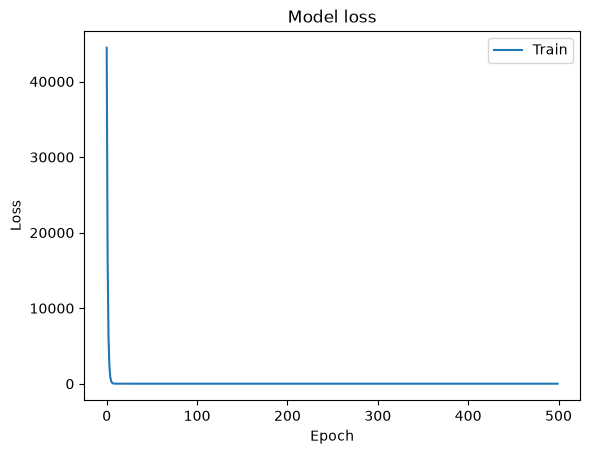

In [10]:
# loss 값의 시각화

import matplotlib.pyplot as plt

plt.plot(loss.history['loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train'], loc='upper right')
plt.show()

In [11]:
# 학습을 통해 구한 w1, w2, w3, bias 값

tf.model.layers[0].get_weights()

[array([[0.05412859],
        [0.91983545],
        [1.0397122 ]], dtype=float32),
 array([0.00995191], dtype=float32)]

In [12]:
# 새로운 데이터로 예측 predict()
tf.model.predict(np.array([[96. ,93. ,95.]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


array([[189.52365]], dtype=float32)